Explainable Transformer Based Framework for Early Detection of Mental Health Disorders from Social Media Text

---

### fine-tuning BERT

This notebook **fine-tunes** `bert-base-uncased` (Devlin et al., 2019) end-to-end for
5-class mental health classification. All 110M encoder weights are updated together
with a classification head (`AutoModelForSequenceClassification`).

Two deliberate differences from the classical ML / DL pipelines:

1. **Raw text, not `clean_text`** — BERT ships with its own WordPiece tokenizer and was
   pre-trained on natural sentences. Stopword removal and lemmatisation destroy the
   syntactic cues (negation, pronouns, function words) that the transformer relies on,
   so the un-cleaned `text` column is used here.
2. **Class-weighted loss** — the training set is imbalanced (Depression 10,509 vs
   Bipolar 1,750), so cross-entropy is weighted inversely to class frequency.

An earlier experiment used BERT as a *frozen* feature extractor ([CLS] embeddings +
Logistic Regression). Its scores are kept as the `BERT (frozen)` baseline so the effect
of fine-tuning can be quantified in the comparison notebook.

Reference: Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL 2019.

In [1]:
import pickle, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)

SPLITS      = Path('..') / 'datasets' / 'processed' / 'splits'
MODELS_DIR  = Path('..') / 'models' / 'saved'
FT_DIR      = MODELS_DIR / 'bert_finetuned'
RESULTS_DIR = Path('..') / 'results'
CHARTS_DIR  = RESULTS_DIR / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
FT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME  = 'bert-base-uncased'
MAX_LEN     = 128
BATCH_SIZE  = 16
EVAL_BATCH  = 64
EPOCHS      = 3
LR          = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_FRAC = 0.1
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
print('device:', DEVICE)

device: mps


---

### load data

The **raw `text`** column is used (see rationale above). Labels come from
`label_encoded` produced in the preprocessing notebook.

In [2]:
train = pd.read_csv(SPLITS / 'train.csv')
val   = pd.read_csv(SPLITS / 'val.csv')
test  = pd.read_csv(SPLITS / 'test.csv')

with open(SPLITS / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)

y_train = train['label_encoded'].values
y_val   = val['label_encoded'].values
y_test  = test['label_encoded'].values

print(f'train / val / test : {len(train):,} / {len(val):,} / {len(test):,}')
print(f'classes            : {CLASS_NAMES}')

train / val / test : 33,159 / 7,106 / 7,106
classes            : ['Anxiety/Stress', 'Bipolar', 'Depression', 'Normal', 'Suicidal']


---

### tokenise

All splits are tokenised once up-front (WordPiece, padded/truncated to 128 tokens).

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextClsDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(texts, max_length=MAX_LEN, padding='max_length',
                             truncation=True, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {'input_ids':      self.enc['input_ids'][i],
                'attention_mask': self.enc['attention_mask'][i],
                'labels':         self.labels[i]}

def texts_of(df):
    return df['text'].fillna('').astype(str).tolist()

train_ds = TextClsDataset(texts_of(train), y_train)
val_ds   = TextClsDataset(texts_of(val),   y_val)
test_ds  = TextClsDataset(texts_of(test),  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=EVAL_BATCH)
test_loader  = DataLoader(test_ds,  batch_size=EVAL_BATCH)

print(f'tokenised — {len(train_ds):,} train batches of {BATCH_SIZE}: {len(train_loader):,} steps/epoch')

tokenised — 33,159 train batches of 16: 2,073 steps/epoch


---

### model, weighted loss, optimiser

The full encoder is trainable. Cross-entropy is weighted by inverse class frequency.
Linear learning-rate warmup over the first 10% of steps, then linear decay — the
standard BERT fine-tuning schedule.

In [4]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'model loaded  |  trainable parameters: {trainable / 1e6:.1f}M (all layers)')

class_weights = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
print('class weights:', {c: round(float(w), 2) for c, w in zip(CLASS_NAMES, class_weights)})

optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * EPOCHS
warmup      = int(total_steps * WARMUP_FRAC)

def lr_lambda(step):
    if step < warmup:
        return step / max(1, warmup)
    return max(0.0, (total_steps - step) / max(1, total_steps - warmup))

scheduler = LambdaLR(optimizer, lr_lambda)
print(f'total steps: {total_steps:,}  |  warmup: {warmup:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model loaded  |  trainable parameters: 109.5M (all layers)
class weights: {'Anxiety/Stress': 1.63, 'Bipolar': 3.79, 'Depression': 0.63, 'Normal': 0.71, 'Suicidal': 0.89}
total steps: 6,219  |  warmup: 621


---

### training loop

After each epoch the model is evaluated on the validation split; the checkpoint with
the best validation macro-F1 is saved to `models/saved/bert_finetuned/`.

In [5]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    preds, labels = [], []
    for batch in loader:
        logits = model(input_ids=batch['input_ids'].to(DEVICE),
                       attention_mask=batch['attention_mask'].to(DEVICE)).logits
        preds.append(logits.argmax(dim=-1).cpu().numpy())
        labels.append(batch['labels'].numpy())
    preds, labels = np.concatenate(preds), np.concatenate(labels)
    return preds, labels

best_val_f1 = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0, running = time.time(), 0.0
    for step, batch in enumerate(train_loader, 1):
        optimizer.zero_grad()
        logits = model(input_ids=batch['input_ids'].to(DEVICE),
                       attention_mask=batch['attention_mask'].to(DEVICE)).logits
        loss = loss_fn(logits, batch['labels'].to(DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        running += loss.item()
        if step % 200 == 0:
            print(f'  epoch {epoch}  step {step:>5}/{len(train_loader)}  '
                  f'loss {running/step:.4f}  ({(time.time()-t0)/60:.1f} min)')

    val_preds, val_labels = evaluate(val_loader)
    val_f1  = f1_score(val_labels, val_preds, average='macro')
    val_acc = accuracy_score(val_labels, val_preds)
    history.append({'epoch': epoch, 'train_loss': running / len(train_loader),
                    'val_acc': val_acc, 'val_macro_f1': val_f1})
    print(f'epoch {epoch} done — train loss {running/len(train_loader):.4f}  '
          f'val acc {val_acc:.4f}  val macro-F1 {val_f1:.4f}  '
          f'({(time.time()-t0)/60:.1f} min)')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(FT_DIR)
        tokenizer.save_pretrained(FT_DIR)
        print(f'  ↳ new best — checkpoint saved to models/saved/bert_finetuned/')

pd.DataFrame(history).to_csv(RESULTS_DIR / 'bert_finetune_history.csv', index=False)
print(f'best validation macro-F1: {best_val_f1:.4f}')

  epoch 1  step   200/2073  loss 1.5331  (2.3 min)


  epoch 1  step   400/2073  loss 1.3220  (4.6 min)


  epoch 1  step   600/2073  loss 1.1413  (6.9 min)


  epoch 1  step   800/2073  loss 1.0034  (9.2 min)


  epoch 1  step  1000/2073  loss 0.9073  (11.5 min)


...

  epoch 3  step  1800/2073  loss 0.2355  (20.9 min)


  epoch 3  step  2000/2073  loss 0.2355  (23.3 min)


epoch 3 done — train loss 0.2360  val acc 0.8278  val macro-F1 0.8328  (25.0 min)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ↳ new best — checkpoint saved to models/saved/bert_finetuned/
best validation macro-F1: 0.8328


---

### evaluation on test set

The best checkpoint (by validation macro-F1) is reloaded and evaluated once on the
held-out test split.

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(FT_DIR).to(DEVICE)

preds, labels = evaluate(test_loader)
bert_acc = accuracy_score(labels, preds)
bert_f1  = f1_score(labels, preds, average='macro')

print('BERT (fine-tuned) — test set')
print(f'  accuracy : {bert_acc:.4f}')
print(f'  macro-F1 : {bert_f1:.4f}')
print()
print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=3))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT (fine-tuned) — test set
  accuracy : 0.8341
  macro-F1 : 0.8410

                precision    recall  f1-score   support

Anxiety/Stress      0.867     0.897     0.882       874
       Bipolar      0.827     0.891     0.858       375
    Depression      0.817     0.728     0.770      2252
        Normal      0.954     0.953     0.953      2014
      Suicidal      0.703     0.786     0.742      1591

      accuracy                          0.834      7106
     macro avg      0.834     0.851     0.841      7106
  weighted avg      0.837     0.834     0.834      7106



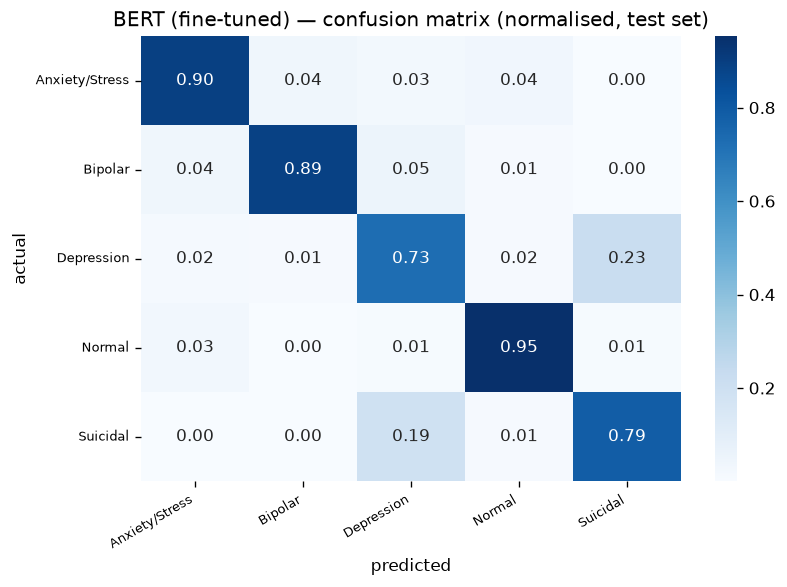

saved: charts/confusion_bert.png


In [7]:
cm     = confusion_matrix(labels, preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('BERT (fine-tuned) — confusion matrix (normalised, test set)')
ax.set_xlabel('predicted')
ax.set_ylabel('actual')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'confusion_bert.png', bbox_inches='tight')
plt.show()
print('saved: charts/confusion_bert.png')

---

### save results

The fine-tuned scores are written alongside the earlier frozen-encoder baseline so the
comparison notebook can show both.

In [8]:
# classification report CSV
report = classification_report(labels, preds, target_names=CLASS_NAMES, output_dict=True)
pd.DataFrame(report).T.round(3).to_csv(RESULTS_DIR / 'classification_report_bert.csv')
print('saved: results/classification_report_bert.csv')

# merge with the frozen-encoder baseline from the earlier experiment
results_path = MODELS_DIR / 'bert_results.json'
bert_results = {}
if results_path.exists():
    with open(results_path) as f:
        old = json.load(f)
    if 'BERT' in old:                      # migrate legacy key
        bert_results['BERT (frozen)'] = old['BERT']
    if 'BERT (frozen)' in old:
        bert_results['BERT (frozen)'] = old['BERT (frozen)']

bert_results['BERT (fine-tuned)'] = {'accuracy': bert_acc, 'macro_f1': bert_f1}

with open(results_path, 'w') as f:
    json.dump(bert_results, f, indent=2)
print('saved: bert_results.json')

if 'BERT (frozen)' in bert_results:
    fr = bert_results['BERT (frozen)']
    print(f"\nfrozen baseline  : acc {fr['accuracy']:.4f}  macro-F1 {fr['macro_f1']:.4f}")
    print(f"fine-tuned       : acc {bert_acc:.4f}  macro-F1 {bert_f1:.4f}")
    print(f"improvement      : +{(bert_f1 - fr['macro_f1']):.4f} macro-F1")

saved: results/classification_report_bert.csv
saved: bert_results.json

frozen baseline  : acc 0.6993  macro-F1 0.6798
fine-tuned       : acc 0.8341  macro-F1 0.8410
improvement      : +0.1612 macro-F1
